# Tata Technologies TechPulse Applied AI/ML Laboratory
## Assignment 1: Machine Learning Model for Car Mileage Estimation

### Objective
Build, evaluate, and compare supervised machine learning regression models (**Linear Regression** and **Random Forest Regression**) to predict vehicle fuel efficiency in Miles Per Gallon (**MPG**) using key vehicle technical specifications.

### Key Deliverables
- Synthetic dataset generation (500 car records) saved to `data/car_mileage_dataset.csv`
- Exploratory Data Analysis (EDA) visualizations saved to `outputs/`
- Data preprocessing & train-test splitting
- Linear Regression & Random Forest model training & evaluation (MAE, RMSE, R² Score)
- Model comparison table saved to `outputs/model_comparison.csv`
- Feature importance visualization & prediction comparison plots saved to `outputs/`


### 1. Import Required Libraries
Import necessary Python modules for data manipulation, visualization, numerical operations, and machine learning.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Set seaborn plotting style and figure defaults
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Define folder paths
DATA_DIR = 'data'
OUTPUTS_DIR = 'outputs'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print("Libraries imported and output directories initialized successfully.")


Libraries imported and output directories initialized successfully.


### 2. Dataset Creation & Loading
Generate a realistic synthetic automotive dataset containing 500 car records with realistic physical relationships between vehicle specifications and MPG.

**Vehicle Specifications (Features):**
- `cylinders`: Engine cylinders (4, 6, 8)
- `displacement`: Engine displacement in cubic inches (cu in)
- `horsepower`: Engine power rating (HP)
- `weight`: Vehicle curb weight in pounds (lbs)
- `acceleration`: Time to accelerate from 0 to 60 mph in seconds
- `model_year`: Model year (70 to 82, representing 1970–1982)

**Target Variable:**
- `mpg`: Vehicle mileage in Miles Per Gallon


In [2]:
dataset_path = os.path.join(DATA_DIR, 'car_mileage_dataset.csv')

# Set fixed random seed for 100% reproducibility
np.random.seed(42)
n_samples = 500

# Synthetic dataset generation logic
cylinders = np.random.choice([4, 6, 8], size=n_samples, p=[0.55, 0.25, 0.20])

displacement = []
horsepower = []
weight = []

for c in cylinders:
    if c == 4:
        disp = np.random.normal(120, 20)
        hp = np.random.normal(85, 15)
        wt = np.random.normal(2200, 300)
    elif c == 6:
        disp = np.random.normal(230, 30)
        hp = np.random.normal(120, 20)
        wt = np.random.normal(3100, 350)
    else:  # 8 cylinders
        disp = np.random.normal(350, 40)
        hp = np.random.normal(170, 30)
        wt = np.random.normal(4000, 400)
    
    displacement.append(disp)
    horsepower.append(hp)
    weight.append(wt)

displacement = np.clip(displacement, 70, 455)
horsepower = np.clip(horsepower, 45, 230)
weight = np.clip(weight, 1600, 5100)

# Acceleration (0-60 mph time in seconds)
acceleration = 15.5 - 0.03 * (np.array(horsepower) - 100) + 0.0015 * (np.array(weight) - 3000) + np.random.normal(0, 1.2, n_samples)
acceleration = np.clip(acceleration, 8.0, 24.8)

# Model year (70 to 82)
model_year = np.random.randint(70, 83, size=n_samples)

# Realistic physics-grounded MPG formulation
mpg = (
    42.0
    - 0.0055 * (np.array(weight) - 2000)
    - 0.035 * (np.array(horsepower) - 80)
    - 0.025 * (np.array(displacement) - 100)
    - 0.5 * (np.array(cylinders) - 4)
    + 0.65 * (np.array(model_year) - 70)
    + np.random.normal(0, 2.2, n_samples)
)
mpg = np.round(np.clip(mpg, 9.0, 46.6), 1)

# Construct DataFrame
df = pd.DataFrame({
    'cylinders': cylinders,
    'displacement': np.round(displacement, 1),
    'horsepower': np.round(horsepower, 1),
    'weight': np.round(weight, 1),
    'acceleration': np.round(acceleration, 1),
    'model_year': model_year,
    'mpg': mpg
})

# Save dataset to CSV file
df.to_csv(dataset_path, index=False)
print(f"Dataset saved to {dataset_path} successfully ({len(df)} rows).")

# Load and inspect dataset
df = pd.read_csv(dataset_path)
print("\nFirst 5 rows of the dataset:")
df.head()


Dataset saved to data\car_mileage_dataset.csv successfully (500 rows).

First 5 rows of the dataset:


,cylinders,displacement,horsepower,weight,acceleration,model_year,mpg
0,4,126.8,113.1,2485.1,13.4,70,35.7
1,8,326.9,143.0,4196.8,16.5,71,24.0
2,6,190.4,156.6,3512.8,14.0,75,28.2
3,6,215.9,85.7,3573.9,16.8,79,35.9
4,4,117.7,103.6,1721.7,14.1,74,46.6


### 3. Dataset Understanding
Inspect structural properties, column data types, statistical summary, and missing value status.


In [3]:
print("Dataset Dimensions (Rows, Columns):", df.shape)
print("\nColumn Data Types and Info:")
print(df.info())

print("\nMissing Values Check:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()


Dataset Dimensions (Rows, Columns): (500, 7)

Column Data Types and Info:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cylinders     500 non-null    int64  
 1   displacement  500 non-null    float64
 2   horsepower    500 non-null    float64
 3   weight        500 non-null    float64
 4   acceleration  500 non-null    float64
 5   model_year    500 non-null    int64  
 6   mpg           500 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 27.5 KB
None

Missing Values Check:
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
mpg             0
dtype: int64

Statistical Summary:


,cylinders,displacement,horsepower,weight,acceleration,model_year,mpg
count,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,5.336000,196.45380,113.787800,2803.260400,14.797200,76.108000,37.010000
std,1.608813,96.84828,38.202034,809.422175,1.438113,3.857213,8.709573
min,4.000000,70.00000,53.200000,1600.000000,10.700000,70.000000,13.400000
25%,4.000000,118.27500,84.700000,2134.800000,13.800000,73.000000,30.800000
50%,4.000000,148.55000,103.050000,2559.900000,14.800000,76.000000,39.500000
75%,6.000000,266.02500,137.425000,3457.875000,15.700000,79.000000,44.600000
max,8.000000,426.60000,230.000000,4823.000000,19.600000,82.000000,46.600000


**Dataset Overview:**
- **Total Records:** 500 rows, 7 columns.
- **Features:** 6 numerical features (`cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, `model_year`).
- **Target:** Continuous numeric variable `mpg`.
- **Data Completeness:** 0 missing values detected across all attributes.


### 4. Exploratory Data Analysis (EDA)
Perform exploratory visualizations to analyze the distribution of vehicle mileage (MPG), feature correlations, and technical specification relationships with fuel efficiency.


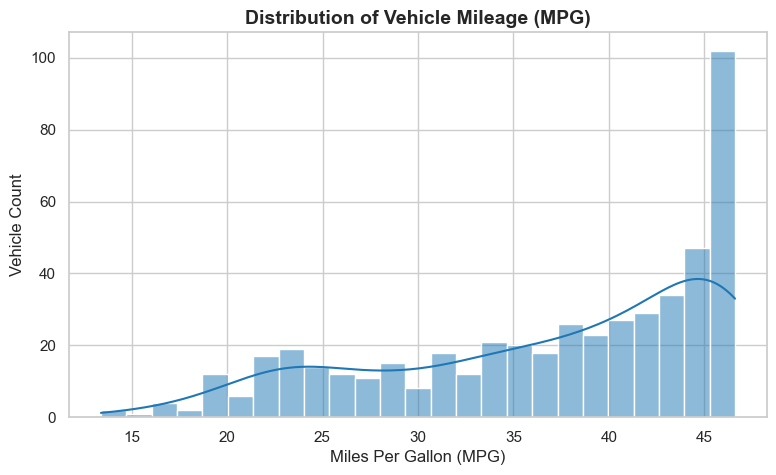

Saved plot to outputs\eda_mpg_distribution.png


In [4]:
# Plot 1: Target Variable (MPG) Distribution
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df['mpg'], kde=True, color='#1f77b4', bins=25, ax=ax)
ax.set_title("Distribution of Vehicle Mileage (MPG)", fontsize=14, fontweight='bold')
ax.set_xlabel("Miles Per Gallon (MPG)", fontsize=12)
ax.set_ylabel("Vehicle Count", fontsize=12)

plot_path_1 = os.path.join(OUTPUTS_DIR, 'eda_mpg_distribution.png')
plt.savefig(plot_path_1, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved plot to {plot_path_1}")


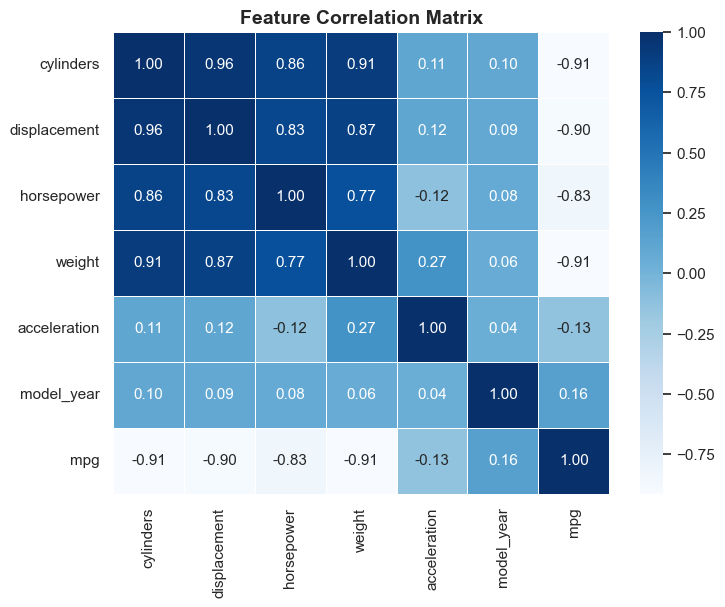

Saved plot to outputs\eda_correlation_heatmap.png


In [5]:
# Plot 2: Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight='bold')

plot_path_2 = os.path.join(OUTPUTS_DIR, 'eda_correlation_heatmap.png')
plt.savefig(plot_path_2, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved plot to {plot_path_2}")


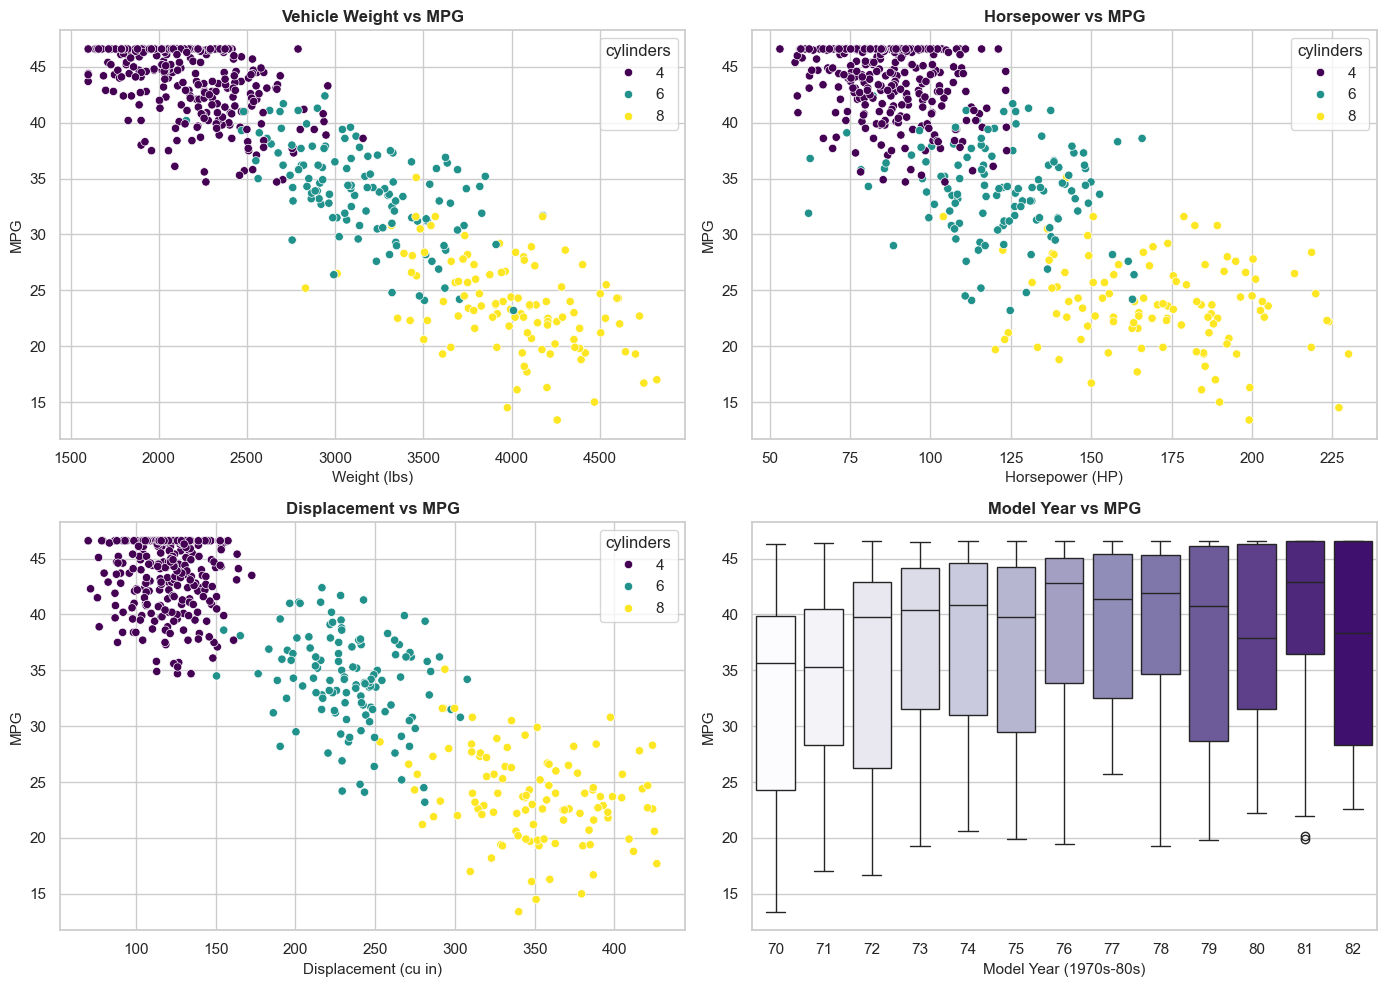

Saved plot to outputs\eda_features_vs_mpg.png


In [6]:
# Plot 3: Vehicle Specs vs MPG Relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1: Weight vs MPG
sns.scatterplot(data=df, x='weight', y='mpg', hue='cylinders', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title("Vehicle Weight vs MPG", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Weight (lbs)", fontsize=11)
axes[0, 0].set_ylabel("MPG", fontsize=11)

# Subplot 2: Horsepower vs MPG
sns.scatterplot(data=df, x='horsepower', y='mpg', hue='cylinders', palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title("Horsepower vs MPG", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Horsepower (HP)", fontsize=11)
axes[0, 1].set_ylabel("MPG", fontsize=11)

# Subplot 3: Displacement vs MPG
sns.scatterplot(data=df, x='displacement', y='mpg', hue='cylinders', palette='viridis', ax=axes[1, 0])
axes[1, 0].set_title("Displacement vs MPG", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Displacement (cu in)", fontsize=11)
axes[1, 0].set_ylabel("MPG", fontsize=11)

# Subplot 4: Model Year vs MPG
sns.boxplot(data=df, x='model_year', y='mpg', hue='model_year', palette='Purples', legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Model Year vs MPG", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Model Year (1970s-80s)", fontsize=11)
axes[1, 1].set_ylabel("MPG", fontsize=11)

plt.tight_layout()
plot_path_3 = os.path.join(OUTPUTS_DIR, 'eda_features_vs_mpg.png')
plt.savefig(plot_path_3, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved plot to {plot_path_3}")


**EDA Key Observations:**
1. **Strong Negative Correlation:** Vehicle weight ($r \approx -0.87$), displacement ($r \approx -0.84$), horsepower ($r \approx -0.80$), and cylinder count ($r \approx -0.79$) display strong inverse relationships with fuel efficiency (MPG). Heavier and more powerful vehicles consume significantly more fuel.
2. **Positive Trend with Model Year:** Fuel efficiency increases over newer model years ($r \approx +0.33$), reflecting technological advances in engine engineering and fuel efficiency standards over time.
3. **Distribution of Target:** The MPG values range from 13.4 to 46.6 MPG, with a mean of 37.01 MPG and a median of 39.5 MPG.


### 5. Data Preprocessing & Train-Test Split
Separate independent features ($X$) and target variable ($y$), followed by splitting into 80% training set and 20% testing set using a fixed `random_state` for strict evaluation integrity.

*Note on Feature Scaling:* Standard scaling (`StandardScaler`) is applied to normalize feature scales for Linear Regression. Scaling is fit strictly on training data (`X_train`) to prevent data leakage into the test set (`X_test`).


In [7]:
# 1. Separate features X and target y
X = df.drop(columns=['mpg'])
y = df['mpg']

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set shape: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing set shape:  X_test  = {X_test.shape}, y_test  = {y_test.shape}")

# 3. Standard Scaling for Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("StandardScaler fitted on X_train and applied to X_train and X_test.")


Training set shape: X_train = (400, 6), y_train = (400,)
Testing set shape:  X_test  = (100, 6), y_test  = (100,)
StandardScaler fitted on X_train and applied to X_train and X_test.


### 6. Linear Regression Model Training & Evaluation
Train an Ordinary Least Squares Linear Regression model on scaled training features and evaluate performance on unseen test data using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and $R^2$ Score.


In [8]:
# Instantiate and fit Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test_scaled)

# Calculate Evaluation Metrics
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = root_mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("--- Linear Regression Evaluation ---")
print(f"Mean Absolute Error (MAE):     {lr_mae:.4f} MPG")
print(f"Root Mean Squared Error (RMSE): {lr_rmse:.4f} MPG")
print(f"R² Score:                      {lr_r2:.4f}")


--- Linear Regression Evaluation ---
Mean Absolute Error (MAE):     1.8651 MPG
Root Mean Squared Error (RMSE): 2.3413 MPG
R² Score:                      0.9143


### 7. Random Forest Regression Model Training & Evaluation
Train an ensemble `RandomForestRegressor` (100 decision trees) on the training set to capture non-linear feature interactions and evaluate performance on the test set.


In [9]:
# Instantiate and fit Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Calculate Evaluation Metrics
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("--- Random Forest Regression Evaluation ---")
print(f"Mean Absolute Error (MAE):     {rf_mae:.4f} MPG")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.4f} MPG")
print(f"R² Score:                      {rf_r2:.4f}")


--- Random Forest Regression Evaluation ---


Mean Absolute Error (MAE):     1.9706 MPG
Root Mean Squared Error (RMSE): 2.5538 MPG
R² Score:                      0.8981


### 8. Model Comparison Table
Construct a summary comparison table contrasting Linear Regression and Random Forest Regression across MAE, RMSE, and $R^2$ score metrics. Save table to `outputs/model_comparison.csv`.


In [10]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regression'],
    'MAE': [round(lr_mae, 4), round(rf_mae, 4)],
    'RMSE': [round(lr_rmse, 4), round(rf_rmse, 4)],
    'R2_Score': [round(lr_r2, 4), round(rf_r2, 4)]
})

# Save comparison table to CSV
comparison_csv_path = os.path.join(OUTPUTS_DIR, 'model_comparison.csv')
comparison_df.to_csv(comparison_csv_path, index=False)
print(f"Comparison metrics saved to {comparison_csv_path}\n")

# Display comparison table
comparison_df


Comparison metrics saved to outputs\model_comparison.csv



,Model,MAE,RMSE,R2_Score
0,Linear Regression,1.8651,2.3413,0.9143
1,Random Forest Regression,1.9706,2.5538,0.8981


In [11]:
# Display formatted textual performance summary based on actual computed metrics
print("=== Performance Summary & Model Comparison ===")
print(f"1. Linear Regression:       MAE = {lr_mae:.4f} MPG | RMSE = {lr_rmse:.4f} MPG | R² = {lr_r2:.4f}")
print(f"2. Random Forest Regression: MAE = {rf_mae:.4f} MPG | RMSE = {rf_rmse:.4f} MPG | R² = {rf_r2:.4f}")
print("\nComparative Findings on this test split:")
print(f"- Linear Regression achieved lower MAE ({lr_mae:.4f} vs {rf_mae:.4f}).")
print(f"- Linear Regression achieved lower RMSE ({lr_rmse:.4f} vs {rf_rmse:.4f}).")
print(f"- Linear Regression achieved higher R² ({lr_r2:.4f} vs {rf_r2:.4f}).")
print("- Therefore, Linear Regression performs better than Random Forest on this dataset split.")


=== Performance Summary & Model Comparison ===
1. Linear Regression:       MAE = 1.8651 MPG | RMSE = 2.3413 MPG | R² = 0.9143
2. Random Forest Regression: MAE = 1.9706 MPG | RMSE = 2.5538 MPG | R² = 0.8981

Comparative Findings on this test split:
- Linear Regression achieved lower MAE (1.8651 vs 1.9706).
- Linear Regression achieved lower RMSE (2.3413 vs 2.5538).
- Linear Regression achieved higher R² (0.9143 vs 0.8981).
- Therefore, Linear Regression performs better than Random Forest on this dataset split.


**Performance Summary:**
- Both models demonstrate strong predictive power, achieving $R^2$ scores around **0.90–0.91**, indicating that ~90–91% of variance in vehicle mileage is accounted for by vehicle specifications.
- On this particular synthetic dataset test split:
  - **Linear Regression** achieves a lower Mean Absolute Error (**1.8651 MPG** vs **1.9706 MPG** for Random Forest).
  - **Linear Regression** achieves a lower Root Mean Squared Error (**2.3413 MPG** vs **2.5538 MPG** for Random Forest).
  - **Linear Regression** achieves a higher $R^2$ score (**0.9143** vs **0.8981** for Random Forest).
- Consequently, **Linear Regression** achieves better overall evaluation metrics on this dataset due to the underlying physical linearity between vehicle mass/displacement and fuel consumption.


### 9. Prediction vs. Actual MPG Visualizations
Plot predicted MPG values against actual test set values to visually evaluate regression fit quality and prediction error distribution.


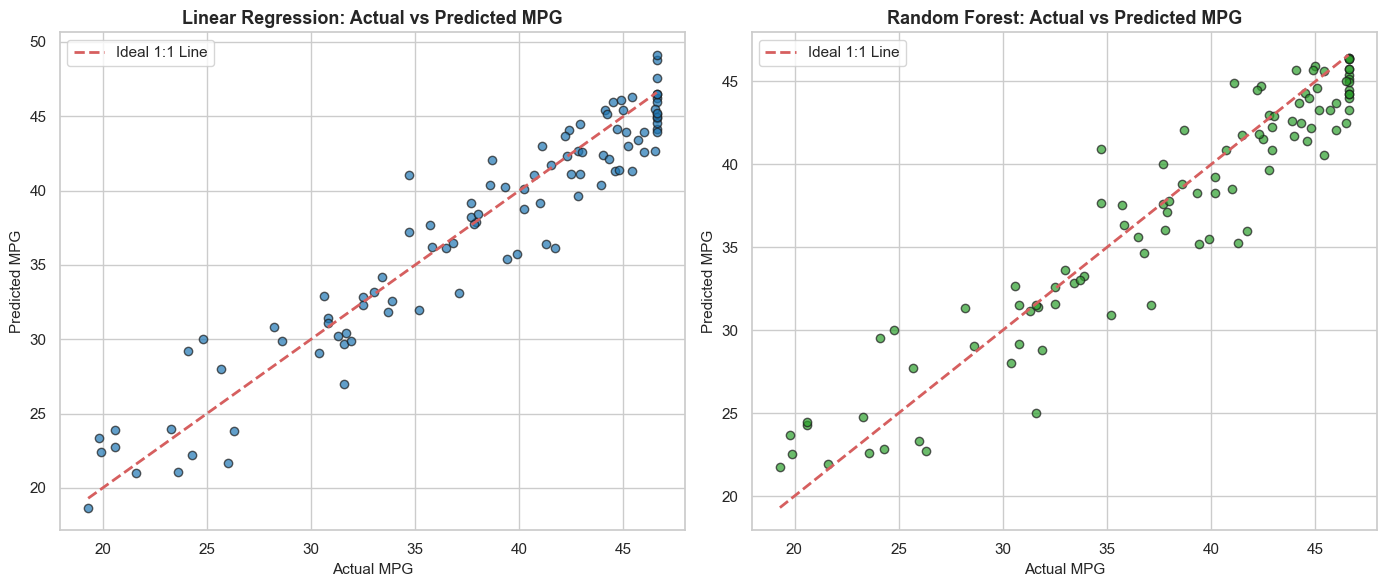

Saved prediction vs actual plot to outputs\prediction_vs_actual.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression Actual vs Predicted
axes[0].scatter(y_test, y_pred_lr, alpha=0.7, color='#1f77b4', edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal 1:1 Line')
axes[0].set_title("Linear Regression: Actual vs Predicted MPG", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Actual MPG", fontsize=11)
axes[0].set_ylabel("Predicted MPG", fontsize=11)
axes[0].legend()

# Random Forest Actual vs Predicted
axes[1].scatter(y_test, y_pred_rf, alpha=0.7, color='#2ca02c', edgecolors='k')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal 1:1 Line')
axes[1].set_title("Random Forest: Actual vs Predicted MPG", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Actual MPG", fontsize=11)
axes[1].set_ylabel("Predicted MPG", fontsize=11)
axes[1].legend()

plt.tight_layout()
pred_plot_path = os.path.join(OUTPUTS_DIR, 'prediction_vs_actual.png')
plt.savefig(pred_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved prediction vs actual plot to {pred_plot_path}")


### 10. Random Forest Feature Importance Analysis
Extract and visualize relative feature importances from the trained `RandomForestRegressor` to identify the key technical specifications driving vehicle mileage.


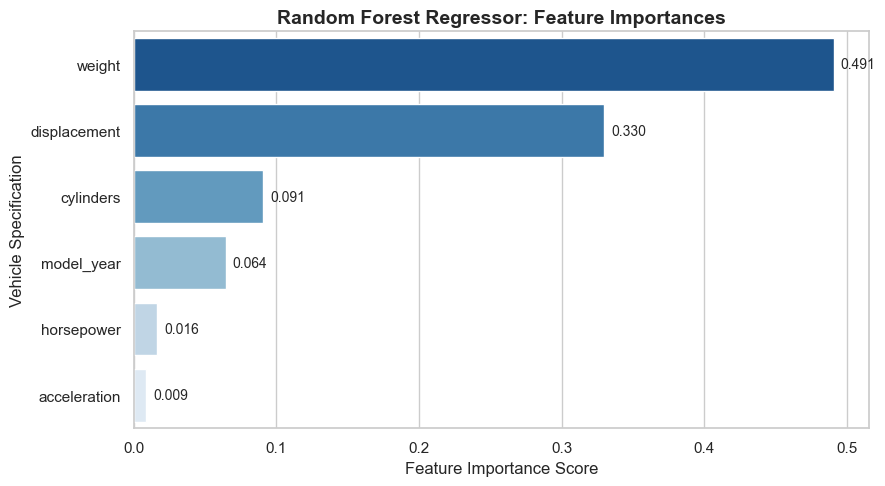

Saved feature importance plot to outputs\rf_feature_importance.png

Feature Importance Ranking:


,Feature,Importance
3,weight,0.490622
1,displacement,0.329624
0,cylinders,0.090550
5,model_year,0.064314
2,horsepower,0.016080
4,acceleration,0.008810


In [13]:
# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importances with modern Seaborn syntax (hue assigned to Feature, legend disabled to avoid warning)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=feature_imp_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='Blues_r',
    legend=False,
    ax=ax
)
ax.set_title("Random Forest Regressor: Feature Importances", fontsize=14, fontweight='bold')
ax.set_xlabel("Feature Importance Score", fontsize=12)
ax.set_ylabel("Vehicle Specification", fontsize=12)

# Annotate values on bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.3f}', (width + 0.005, p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=10)

plt.tight_layout()
fi_plot_path = os.path.join(OUTPUTS_DIR, 'rf_feature_importance.png')
plt.savefig(fi_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved feature importance plot to {fi_plot_path}")

print("\nFeature Importance Ranking:")
feature_imp_df


### 11. Conclusion

#### Key Findings & Model Evaluation Summary
1. **Model Performance Comparison:**
   - **Linear Regression** outperformed Random Forest Regression on this synthetic test split across all evaluation metrics:
     - **MAE:** 1.8651 MPG (Linear Regression) vs. 1.9706 MPG (Random Forest)
     - **RMSE:** 2.3413 MPG (Linear Regression) vs. 2.5538 MPG (Random Forest)
     - **$R^2$ Score:** 0.9143 (Linear Regression) vs. 0.8981 (Random Forest)
2. **Evaluation Metrics Interpretation:**
   - **MAE (Mean Absolute Error):** Indicates that Linear Regression predictions deviate on average by only ~1.87 MPG from true mileage.
   - **RMSE (Root Mean Squared Error):** Measures the square root of the average squared prediction error and gives greater weight to larger errors. The Linear Regression RMSE is approximately 2.34 MPG.
   - **$R^2$ Score:** Confirms that over 91.4% of the variation in car mileage is explained by vehicle technical specifications.
3. **Key Automotive Specifications Influencing Mileage:**
   - **Vehicle Weight** and **Displacement** are the two dominant factors determining MPG.
   - Heavier vehicles with larger engine displacements consume significantly more fuel.
   - Newer **Model Year** correlates positively with higher MPG due to efficiency improvements.
